## algorithm design and anlysis-2026 spring  homework 1 
**Deadline**：2026.5.20

**name**:


note：
---
1. 带有\*的题目，申请免上课的同学，必须完成，其他同学选作；
2. 请独立完成，如求助了他人或者大模型，请著明，并且不可省略算法分析部分；
4. 如若作答有雷同，全部取消成绩；
3. 需要书面作答的题目，可以通过引用图片的形式添加，但是注意上传项目时包含所引用的图片的源文件；
4. $log_n$ 默认表示$log_2{n}$;

## 问题 1

根据下列递归公式, 计算下列 $T(n)$ 对应的的渐近上界。要求所求的边界尽可能的紧（tight）, 请写明步骤。

1. $T(1)=1; T(n)=T(n/4)+1$ for $n>1$
2. $T(1)=1;T(n)=3T(n/3)+n^2$ for $n>1$
3. $T(1)=1;T(n)=T(2n/3)+1$ for $n>1$
4. $T(1)=1;T(n)=5T(n/4)+n$ for $n>1$
5. $T(n)=1 \ for\ n \le 2 ; T(n)=T(\sqrt{n})+1 \ for \ n>2$

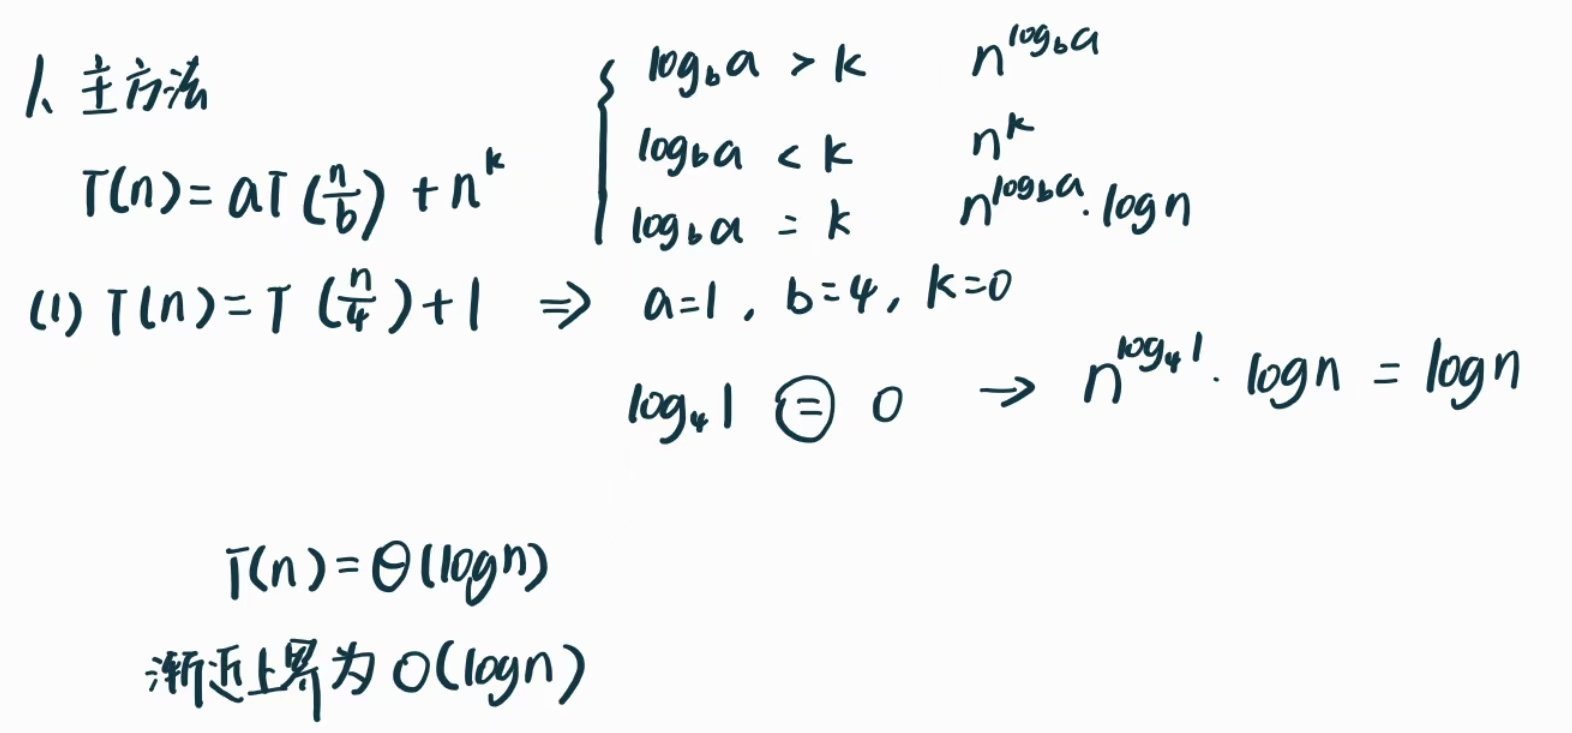

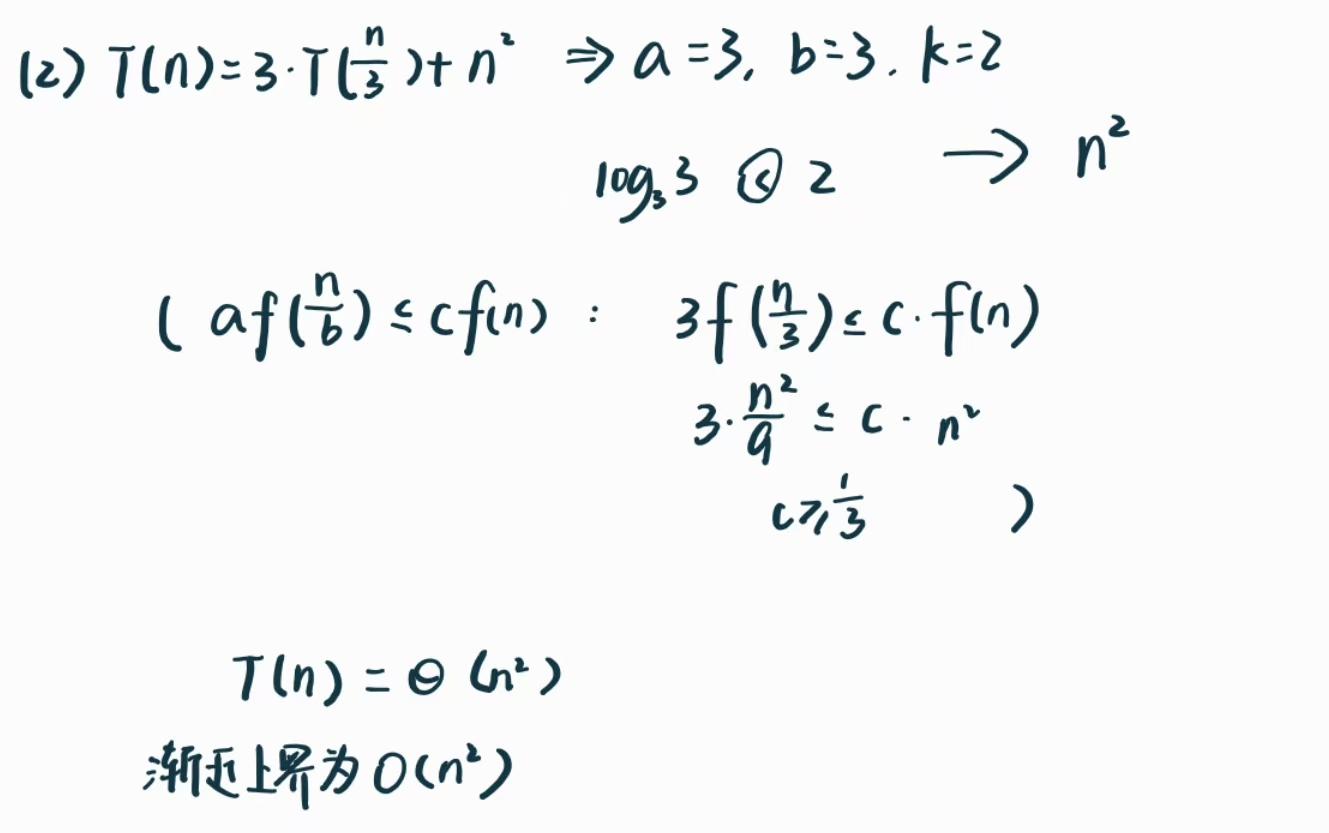

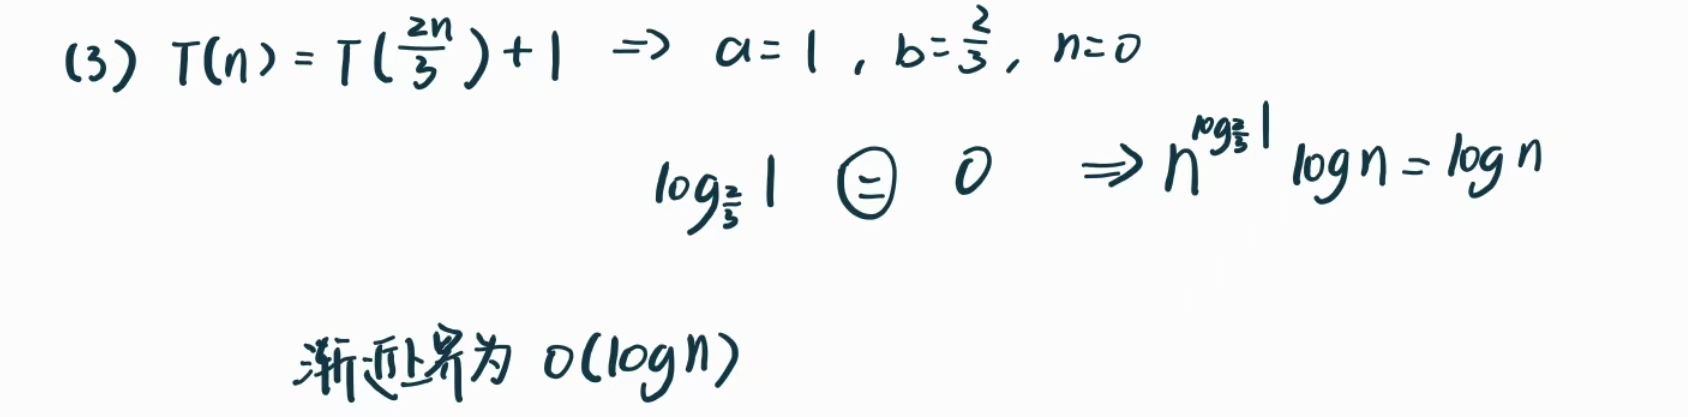

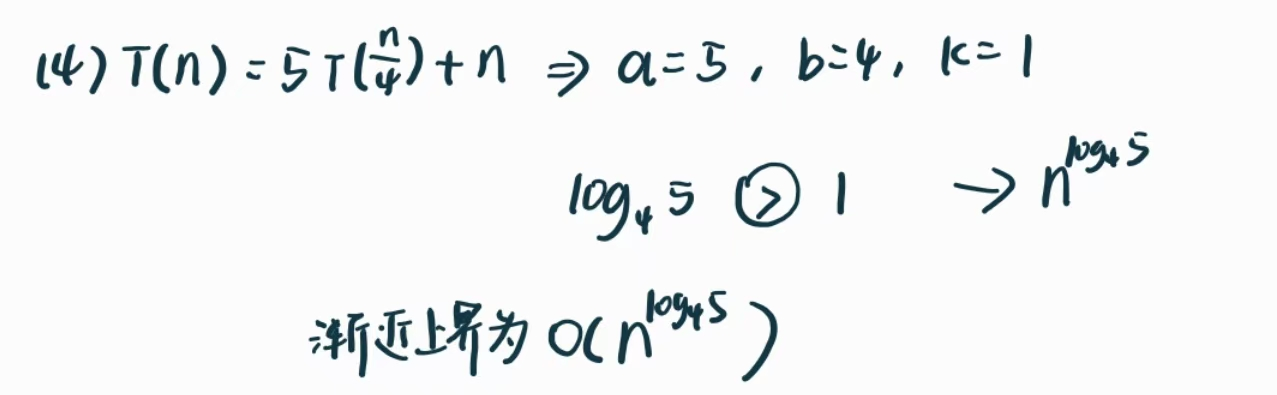

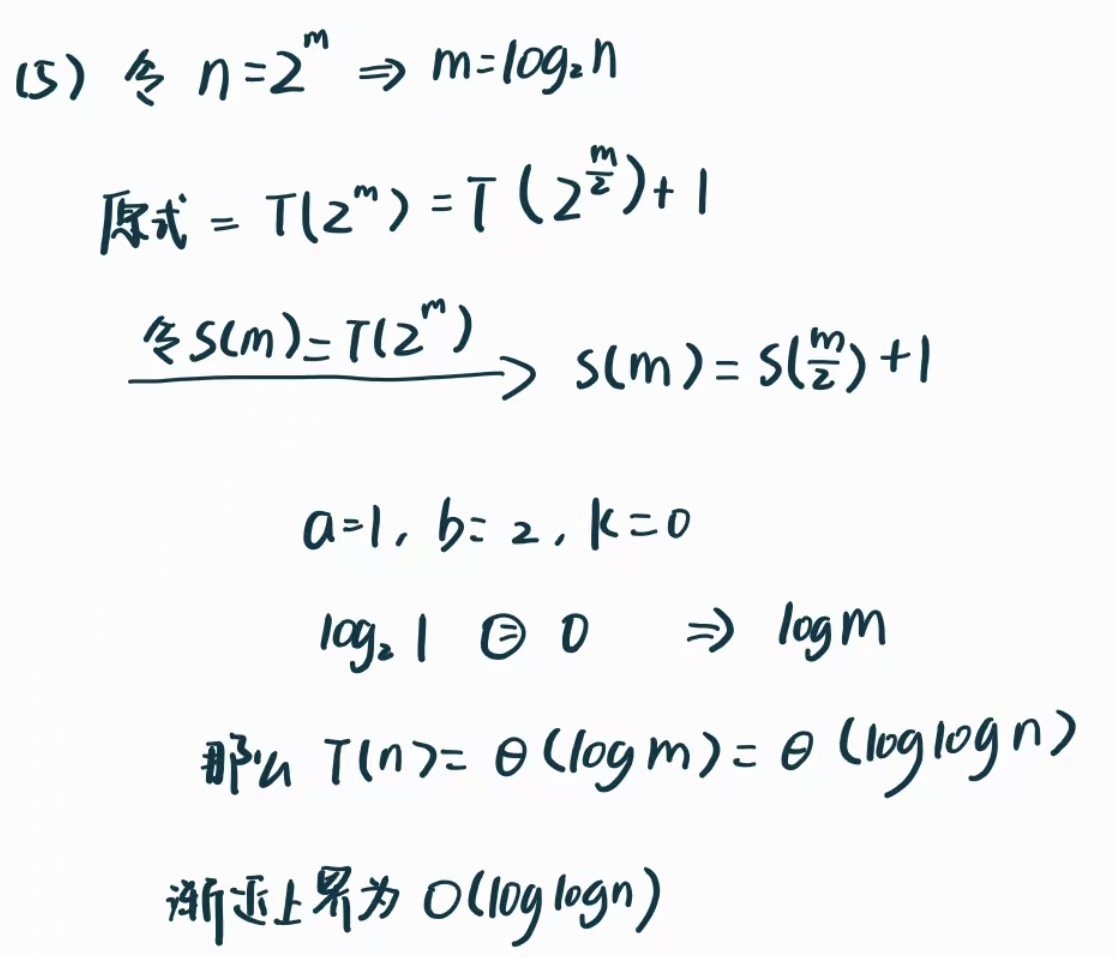

In [6]:
from IPython.display import Image, display
from IPython.core.display import HTML

# 禁用输出滚动
display(HTML("<style>.jp-OutputArea-child { display: block; overflow-x: visible !important; overflow-y: visible !important; }</style>"))

display(Image(filename='fig/1.jpg', width=400))
display(Image(filename='fig/1.2.jpg', width=400))
display(Image(filename='fig/1.3.jpg', width=400))
display(Image(filename='fig/1.4.jpg', width=400))
display(Image(filename='fig/1.5.jpg', width=400))

## 问题 2

观察下方的分治算法（divide-and-conquer algorithm）的伪代码, 回答下面问题

```latex
DoSomething(A,p,r)
-----
n := r-p+1
if n=2 and A[p]>A[r] then
    swap A[p] and A[r]
else if n >= 3 then
    m = ceil(2n/3)
    DoSomething(A,p,p+m-1)
    DoSomething(A,r-m+1,r)
    DoSomething(A,p,p+m-1)  
    
---
first call: DoSomething(A,1,n)
```

note：$ceil(2n/3)=\left\lceil {2n/3} \right\rceil$；$:=$ 表示赋值, 等价于 $\to$；A是一个包含n的整数元素的数组, 

1. 写出该算法时间复杂度的递归公式, 并求解其对应的渐进表示
2. 描述一下该算法的功能, 并判断是否是最高效的解决方案
3. \* 使用python编程实现上述算法或其对应的更高效版本的算法

idea: 
（借助了大模型）

2. 该算法的功能是对数组进行升序排序。
其核心逻辑是：先将前2/3的元素排序，再将后2/3的元素排序（这保证了数组中最大的1/3元素一定被移到了数组的末尾），最后再次将前2/3的元素排序（将前面剩余的元素排序好），最终得到完全有序的数组。
不是最高效的解决方案，因为时间复杂度很高。

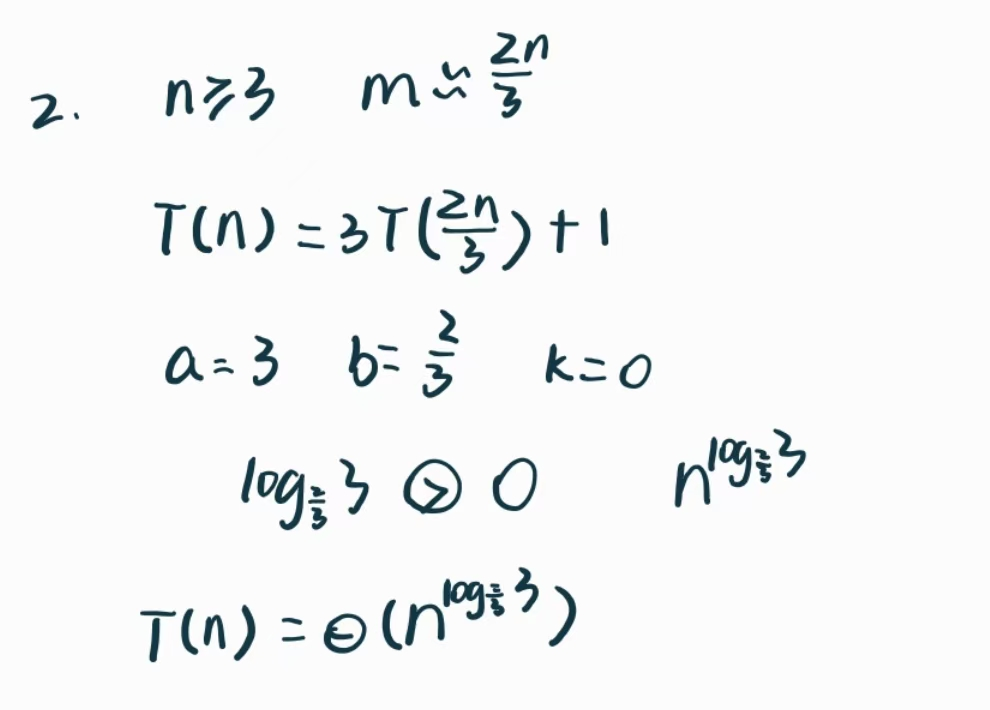

In [7]:
# add your code here
from IPython.display import Image

# 插入单张图片
Image(filename='fig/2.jpg')
# your algorithm time complexity is:

## 问题 3

给定一个包含n个元素的数组 `profits` , 它的第 `i` 个元素 `profits[i]` 表示一支股票第 `i` 天的**收益**（正数表示涨, 负数表示跌）。你只能选择 **某一天** 买入这只股票, 并选择在 **未来的某一个不同的日子** 卖出该股票。

1. 设计一个算法来计算你所能获取的最大利润和对应买入和卖出的日期。请分析算法方案, 计算其时间复杂度, 并且使用python编程实现该算法。

2. \* 设计一个时间复杂度为 $O(n)$的算法实现该算法

e.g. :
---
profits=[3,2,1,-7,5,2,-1,3,-1], 第5天买入, 第8天卖出, 收益最大：9

idea:（借助了大模型）
枚举所有可能的买入日期和卖出日期，计算它们之间的收益总和，并找出最大值。我们可以使用双层循环，外层循环选定买入的起始天数i，内层循环选定卖出的结束天数j(j ≥ i)，同时维护一个当前区间的和，并不断更新全局最大值。

In [10]:
# add your code here
def max_profit_n2(profits):
    n = len(profits)
    if n == 0:
        return 0, -1, -1

    max_profit = float('-inf')
    buy_day = -1
    sell_day = -1

    # 枚举所有可能的买入和卖出组合
    for i in range(n):
        current_sum = 0
        for j in range(i, n):
            current_sum += profits[j]
            # 如果当前区间收益更大，则更新最大收益及对应的日期
            if current_sum > max_profit:
                max_profit = current_sum
                # 题目示例中天数是从 1 开始计算的，所以索引需要 +1
                buy_day = i + 1
                sell_day = j + 1

    return max_profit, buy_day, sell_day

# 测试示例
profits_example = [3, 2, 1, -7, 5, 2, -1, 3, -1]
profit, buy, sell = max_profit_n2(profits_example)
print(f"O(n^2) 算法 - 第{buy}天买入，第{sell}天卖出，收益最大：{profit}")
# your algorithm time complexity is: O(n^2)

O(n^2) 算法 - 第5天买入，第8天卖出，收益最大：9


## 问题 4

给定一个包含不同整数元素的数组 $ A[1..n]$ ,并且满足条件：$A[1]>A[2]$ 并且 $A[n-1]<A[n]$; 规定：如果一个元素比它两边的邻居元素都小, 即：$A[x]<A[x-1], A[x]<A[x+1]$ , 称这个元素A[x]为“局部最小”。通过遍历一次数组, 我们可以很容易在 $O(n)$的时间复杂度下找到一个局部最小值, 


1. 分析该问题, 设计一个算法在$O(logn)$的时间复杂度下找到一个局部最小(返回数值), 要求：分析算法设计思路, 并且使用python编程实现
2. \* 设计算法找出所有局部最小值, 分析算法设计思路, 并使用python编程实现

e.g.:
---
A=[9, 3, 7, 2, 1, 4, 5 ] 时,  局部最小元素为 3, 1

idea: （借助了大模型）
要想达到 $O(\log n)$ 的时间复杂度，我们需要使用二分查找法。取数组中间的元素 mid。情况 A：如果 A[mid] < A[mid-1] 且 A[mid] < A[mid+1]，那么 A[mid] 就是我们要找的局部最小，直接返回。情况 B：如果 A[mid] > A[mid+1]，说明 mid 位置处于下降趋势。结合末尾是上升的条件，在 mid 的右侧必然至少存在一个谷底。所以我们将搜索区间缩小到右半部分。情况 C：如果 A[mid] > A[mid-1]，说明 mid 位置处于上升趋势。结合开头是下降的条件，在 mid 的左侧必然至少存在一个谷底。将搜索区间缩小到左半部分。

In [1]:
# add your code here
def find_all_local_minimums(arr):
    n = len(arr)
    local_minimums = []
    
    # 遍历索引 1 到 n-2
    for i in range(1, n - 1):
        if arr[i] < arr[i - 1] and arr[i] < arr[i + 1]:
            local_minimums.append(arr[i])
            
    return local_minimums

# 测试用例
A = [9, 3, 7, 2, 1, 4, 5]
result_all = find_all_local_minimums(A)
print(f"所有的局部最小值: {result_all}")
# your algorithm time complexity is:  O(n)

所有的局部最小值: [3, 1]


## 问题 5

给定包含n个不同数字的一组数, 寻找一种基于比较的算法在这组数中找到k个最小的数字, 并按顺序输出它们。

1. 将n个数先进行排序, 然后按顺序输出最小的k个数。要求：选择合适的排序算法实现上述操作, 计算算法时间复杂度, 并使用python编程实现。
2. 建立一个包含这n个数的堆（heap）, 并且调用 k 次Extract-min 按顺序输出最小的k个数。使用往空堆中不断插入元素的方法建立堆, 分析这种方法建堆的时间复杂度, 并使用python编程实现
3. \* 假设数组中包含的数据总数目超过了计算机的存储能力, 请设计一个算法, 找到这堆数据的前k小的数值, 计算时间复杂度, 并使用python实现该算法, 假设计算机一定能存储k个数据。

e.g.：
---
数组arr=[5,4,3,2,6,1,88,33,22,107] 的前3个最小数据为：1, 2, 3

idea:（借助了大模型）
1. 首先利用基于比较的高效排序算法对包含n个不同数字的整个数组进行升序排序，该排序算法在最坏情况下的时间复杂度为O(n log n)；排序完成后，数组中的元素已按从小到大的顺序排列，此时直接取出前k个元素即为最小的k个数，并按顺序输出。
2. 首先初始化一个空堆，然后遍历包含n个不同数字的数组，将每个元素通过插入操作逐一加入堆中；建堆完成后，连续调用k次提取最小值操作，每次提取需要O(log n)时间来重新调整堆结构，从而按升序依次输出最小的k个数。

In [9]:
# add your code here
1.
def top_k_by_sorting(arr, k):
    # 使用 Python 内置的优秀排序算法（Timsort）进行升序排序
    sorted_arr = sorted(arr)
    # 截取前 k 个最小的数字
    return sorted_arr[:k]

# 测试用例
arr = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
k = 3
print(f"一输出: {top_k_by_sorting(arr, k)}")
# your algorithm time complexity is: O(n log n)

2.
import heapq

def top_k_by_min_heap(arr, k):
    min_heap = []
    
    # 1. 往空堆中不断插入元素建堆
    for num in arr:
        heapq.heappush(min_heap, num)
        
    # 2. 调用 k 次 Extract-min (在 Python 中为 heappop)
    result = []
    for _ in range(k):
        if min_heap:
            result.append(heapq.heappop(min_heap))
            
    return result

# 测试用例
arr = [5, 4, 3, 2, 6, 1, 88, 33, 22, 107]
k = 3
print(f"二输出: {top_k_by_min_heap(arr, k)}")
# your algorithm time complexity is: O(n log n)

一输出: [1, 2, 3]
二输出: [1, 2, 3]


## 问题 6

> 星球碰撞问题：现有n个星球，在同一条直线上运行，如数组A所示，元素的绝对值表示星球的质量，负数表示星球自右向左运动，正数表示星球自左向右运动，当两个星球相撞的时候，质量小的会消失，大的保持不变，**质量相同的两个星球碰撞后自右向左运动的星球消失，自左向右的星球保持不变**，假设所有星球的速度大小相同。
>
> $ A=[23,-8, 9, -3, -7, 9, -23, 22] $

请设计一个算法模拟星球的运行情况，输出最终的星球存续情况（输出一个数组），分析算法设计思路，计算时间复杂度，并基于python编程实现。

e.g.
---
1.  输入： A=[-3,-6,2,8, 5,-8,9,-2,1]， 输出：[-3, -6, 2, 8, 9, 1]

2. 输入：A=[23,-8, 9, -3, -7, 9, -23, 22], 输出：[23, 22]

idea:（借助了大模型）
使用栈的数据结构进行模拟，利用后进先出的特性来动态维护存活星球的序列。算法的核心在于顺序遍历星球数组时，通过栈顶元素与当前星球的运动方向及质量来判定并处理空间冲突。只有当栈顶星球向右运动且当前星球向左运动时，才会触发碰撞。在碰撞过程中，程序会持续比较两者的质量绝对值：若栈顶星球质量较小，则将其出栈，并令当前星球继续与新的栈顶元素进行下一轮碰撞判定；若两者质量相等，向左运动的当前星球损毁，向右运动的栈顶星球保留，当前判定随之终止；若栈顶星球质量较大，则当前星球直接损毁并终止判定。对于未触发碰撞条件或在连环碰撞中最终存活的星球，算法将其压入栈中。遍历结束后，栈内保留的元素序列即为最终的星球存续状态。

In [8]:
# add your code here

def simulate_planets(A):

    stack = []
    
    for p in A:
        # alive 用于标记当前正在处理的星球 p 是否存活
        alive = True
        
        # 当满足碰撞条件时：p向左运动(<0) 且 栈顶星球向右运动(>0)
        while alive and p < 0 and stack and stack[-1] > 0:
            if stack[-1] < abs(p):
                stack.pop()
            elif stack[-1] == abs(p):
                alive = False
            else:
                alive = False
                
        # 如果经过一系列碰撞后，当前星球 p 仍然存活（或者一开始就没有发生碰撞条件）
        if alive:
            stack.append(p)
            
    return stack

# --- 测试运行 ---
A = [23, -8, 9, -3, -7, 9, -23, 22]
result = simulate_planets(A)

print(f"初始星球运行情况: {A}")
print(f"最终星球存续情况: {result}")
# your algorithm time complexity is: O(n)


初始星球运行情况: [23, -8, 9, -3, -7, 9, -23, 22]
最终星球存续情况: [23, 22]


## 问题 7

> 0-1背包问题：现在有4块大理石，每个大理石对应的重量和价值使用一个元组表示, 即（重量，价值），4块大理石的重量和价值为：[(5,10), (4,40), (6,30), (3, 50)], 假设你有一辆最大承重为9的小推车，请问使用这个小推车装大理石的最大价值为多少

请设计一个算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:（借助了大模型）
通过构建状态转移方程，利用局部的历史最优状态来推导全局的最优解。具体而言，我们可以定义一个一维数组来记录不同承重容量下所能获得的最大价值。遍历每一块大理石时，对于推车可能的每一个容量（为了保证每块大理石只被选择一次，容量需要从最大承重开始向小逆序遍历），我们需要做出“装”与“不装”的决策。如果推车当前剩余容量装不下这块大理石，那么当前容量下的最大价值保持不变；如果能装下，则需要比较“不装这块大理石的价值”与“装上这块大理石后，剩余容量能带来的最大价值加上这块大理石自身的价值”，并取两者中的最大值来更新当前状态。当所有大理石都判断完毕后，数组在最大承重位置所记录的数值，即为能够装载的最大总价值。

In [4]:
# add your code here
def knapsack_01(items, max_weight):
    dp = [0] * (max_weight + 1)
    
    for weight, value in items:
        # 逆序遍历容量，确保每个物品只能被放入一次
        for w in range(max_weight, weight - 1, -1):
            # 状态转移：比较“不放入当前物品”和“放入当前物品”的价值，取最大值
            dp[w] = max(dp[w], dp[w - weight] + value)
            
    # dp数组的最后一个元素即为最大承重下的最大价值
    return dp[max_weight]

# --- 测试运行 ---
marbles = [(5, 10), (4, 40), (6, 30), (3, 50)]
cart_capacity = 9

max_value = knapsack_01(marbles, cart_capacity)

print(f"大理石重量与价值: {marbles}")
print(f"小推车最大承重: {cart_capacity}")
print(f"装载大理石的最大价值为: {max_value}")
# your algorithm time complexity is: O(N * W)，N为大理石的总数量，W为小推车的最大承重限制

大理石重量与价值: [(5, 10), (4, 40), (6, 30), (3, 50)]
小推车最大承重: 9
装载大理石的最大价值为: 90


## 问题 8

给你二叉搜索树的根节点 root ，该树中的恰好两个节点的值被错误地交换。请在不改变其结构的情况下，恢复这棵树 。设计算法解决该问题，分析算法设计思路，计算时间复杂度，并基于python编程实现

e.g.:
---
1.

<div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入：root = [1,3,null,null,2]， 输出为：[3,1,null,null,2]， 

解释：3 不能是 1 的左孩子，因为 3 > 1 。交换 1 和 3 使二叉搜索树有效。

2.

 <div style="text-align:center;width:200px;"> <img alt="" src="./fig/hw3q9-1.jpg"> </div>
输入： root=[3,1,4,null,null,2]， 输出为：[2,1,4,null,null,3]

解释：2 不能在 3 的右子树中，因为 2 < 3 。交换 2 和 3 使二叉搜索树有效。

idea:（借助了大模型）

利用二叉搜索树的性质
二叉搜索树的一个核心性质是：它的中序遍历（左-根-右）序列一定是一个严格递增的序列。
在进行中序遍历时，我们需要维护一个 prev 指针，记录上一个访问的节点。
将当前节点 node 的值与 prev 的值进行比较。如果发现 prev.val > node.val，说明找到了一个降序位置。
使用两个指针 first 和 second 来记录需要交换的节点。
遇到第一个降序对时，将 prev 赋给 first，将 node 赋给 second；
遇到第二个降序对时，只需更新 second 为当前的 node。
遍历结束后，直接交换 first 和 second 节点内的值即可恢复树的结构。

In [6]:
# add your code here
# Definition for a binary tree node.
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def recoverTree(self, root: TreeNode) -> None:
        """
        Do not return anything, modify root in-place instead.
        """
        # 初始化指针
        self.first = None
        self.second = None
        # 初始化前驱节点为负无穷大，确保第一个节点比较时不会被误判
        self.prev = TreeNode(float('-inf')) 
        
        def inorder(node: TreeNode):
            if not node:
                return
            
            # 1. 遍历左子树
            inorder(node.left)
            
            # 2. 处理当前节点
            # 如果发现前一个节点的值大于当前节点的值，说明出现了逆序
            if self.prev.val > node.val:
                # 如果是第一次遇到逆序对，记录第一个错误节点为 prev
                if self.first is None:
                    self.first = self.prev
                # 无论是否是第一次，第二个错误节点目前看来都是当前的 node
                # 如果这是第二个逆序对，这行代码会更新 second 为真正需要交换的较小节点
                self.second = node
            
            # 更新 prev 指针为当前节点
            self.prev = node
            
            # 3. 遍历右子树
            inorder(node.right)
            
        # 执行中序遍历
        inorder(root)
        
        # 遍历完成后，交换这两个错误节点的值
        if self.first and self.second:
            self.first.val, self.second.val = self.second.val, self.first.val
# your algorithm time complexity is: O(N)

## 问题 9 \*
给定 `n` 个非负整数表示每个宽度为 `1` 的柱子的高度图，计算按此排列的柱子，下雨之后能接多少雨水。



<div style="text-align:center;width:800px;"> <img alt="" src="./fig/hw3q6.png"> </div>

请分析算法设计思路，计算时间复杂度，并基于python编程实现

idea:

In [ ]:
# add your code here
# your algorithm time complexity is:

## 问题 10

给你一个二叉树的根节点 root ，树中每个节点都存放有一个 0 到 9 之间的数字。每条从根节点到叶节点的路径都代表一个数字：

> 例如，从根节点到叶节点的路径 1 -> 2 -> 3 表示数字 123 。

设计一个算法计算从根节点到叶节点生成的所有数字之和 ，分析算法设计思路，计算时间复杂度，并基于python编程实现

叶节点:是指没有子节点的节点。

e.g.:
---
1.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-1.jpg"> </div>

 输入：root = [1,2,3], 输出：25

解释：从根到叶子节点路径 1->2 代表数字 12，1->3 代表数字 13，因此和为 12 + 13 = 25 。

2.

 <div style="text-align:center;width:200px;"> <img alt="figure" src="./fig/hw3q10-2.jpg"> </div>

 输入：root = [4,9,0,5,1], 输出：1026

解释：从根到叶子节点路径 4->9->5 代表数字 495，4->9->1 代表数字 491，4->0 代表数字 40。因此和为 495 + 491 + 40 = 1026 。

idea:（借助了大模型）
遍历时系统维护一个动态累加值，每深入一层，便根据十进制规则将父节点传入值乘以10并累加当前节点值，实现状态更新。遇空节点返回0；若当前节点无左右子树即为叶子节点，说明单条完整路径拼装完毕，直接返回该累加数字。对于非叶子节点，它承担枢纽作用，负责将更新后的数字继续分发给左右子树深入搜索，待子树各自完成底层叶子节点求和后，再收集并相加左右子树的返回值。通过这种先自顶向下传递计算、再自底向上归并结果的层层回溯机制，最终在根节点合并出整棵树所有路径数字的总和。

In [7]:
# add your code here
# 二叉树节点的定义
class TreeNode:
    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right

class Solution:
    def sumNumbers(self, root: TreeNode) -> int:
        def dfs(node: TreeNode, current_sum: int) -> int:
            # 如果节点为空，对总和的贡献为 0
            if not node:
                return 0
            
            # 计算包含当前节点的路径数字
            current_sum = current_sum * 10 + node.val
            
            # 如果当前节点是叶子节点，返回计算好的数字
            if not node.left and not node.right:
                return current_sum
            
            # 如果不是叶子节点，递归遍历左右子树，并将它们的路径和相加
            left_sum = dfs(node.left, current_sum)
            right_sum = dfs(node.right, current_sum)
            
            return left_sum + right_sum
        
        # 从根节点开始 DFS，初始路径数字为 0
        return dfs(root, 0)

# 测试代码 (对应示例 2)
if __name__ == "__main__":
    # 构建测试用例: [4,9,0,5,1]
    root = TreeNode(4)
    root.left = TreeNode(9)
    root.right = TreeNode(0)
    root.left.left = TreeNode(5)
    root.left.right = TreeNode(1)

    sol = Solution()
    result = sol.sumNumbers(root)
    print(f"输出: {result}")  # 预期输出: 1026
# your algorithm time complexity is: O(N)

输出: 1026
